# GENE7 — does morphology add information about the transcriptome?

**The question.** Crispants are mosaic F0s: an injected clutch mixes embryos with effective biallelic
disruption against escapers with little or none. If morphological severity tracks that hidden dose,
then grading embryos by how perturbed they *look* should sharpen the transcriptional signal relative
to a plain crispant/control label.

This notebook condenses the full chain of reasoning. Each detailed analysis lives in a companion
notebook; here the aim is a single coherent account with every number traceable to a file.

**Summary of what was found**

| # | finding | status |
|---|---|---|
| 1 | Supervised morphology axes have genuine predictive power, but **do not outperform** knowing the class label | established |
| 2 | The continuous-axis and binary-label transcriptional effects are **strongly aligned** (cosine 0.91); ~17% of the variance is orthogonal — real biology or noise, likely case-dependent | established |
| 3 | Severe crispants trend stronger than escapers, **not significant** on the paired test; more striking is that **wildtype-looking crispants are substantially perturbed** | mixed |
| 4 | Adding an **intra-class** morphology term gives a significant slope in **9–10 of 36** perturbations, concentrated in those with stronger morphology axes | established (the concentration is suggestive) |
| 5 | That term resolves **76 cell-type effects the label alone misses**, against **1** in a matched negative control | the headline claim |

---

## 0. Provenance — where every number comes from

**Morphology.** Legacy VAE latents (`z_mu_b_*`, the 80 biological dimensions), assembled per embryo
by `build_master_table()` in `src/morphseq_integration/`. GENE7 is imaging experiment `20250612`.
**14 wells** are dropped by curated image QC (`src/morphseq_integration/excluded_wells.csv`), leaving
**553 embryos**. Design: 3 crispant targets (`atf6`, `ctcf`, `wfs1a/wfs1b`) plus `Control`, at 4
rearing temperatures (24/28/34/35 °C) x 3 collection timepoints (24/30/36 hpf).

**Sequencing.** The v3.1.0 embryo-filtered CDS at
`/net/seahub_zfish/.../portal_inputs/v3.1.0/mcclintock/GENE7/run_1/filter_embryos/embryo_filtered_cds`.
Reduced once by `build_count_table.R` to a cell-type x embryo count matrix: **370 cell types x 651
embryos, 1,894,015 cells**, median 2,341 cells per embryo. Native `cell_type` annotations, not
`cell_type_broad`. The 8.4 GB object is never touched again.

**Overlap.** 535 embryos carry both modalities. 18 embryos have morphology but no cells in the CDS
(§0 table below); 116 sequenced embryos were never imaged.

**Coordinate system.** A GENE7-native 10-component PCA on `z_mu_b_*`, unwhitened; the **first 5**
components are the working subspace. GENE7-native matters — a wildtype-fit basis would pre-filter out
the perturbation directions this analysis is looking for.

| artifact | written by | holds |
|---|---|---|
| `data/gene7_global_scores.csv` | `run_cohort_axes.py` | 553 embryos in the 10D basis |
| `data/lda/contrast_summary.csv` | `run_lda_contrasts.py` | per-contrast axis diagnostics |
| `data/lda/contrast_scores.csv` | `run_lda_contrasts.py` | per-embryo signed distance `s` |
| `data/edger/cell_counts.csv` | `build_count_table.R` | 370 x 651 count matrix |
| `data/edger/contrast_predictors.csv` | `export_edger_inputs.py` | the 7 regression predictors |
| `data/edger/coefficients.csv` | `fit_edger_contrasts.R` | per (contrast, arm, cell type) |
| `data/edger/global_stats.csv` | `fit_edger_contrasts.R` | per (contrast, arm) global statistic |

Companion notebooks: `gene7_lda_contrasts.ipynb` (axis construction and validation),
`gene7_morphospace.ipynb` (PCA and reference spline), `gene7_edger_results.ipynb` (full regression
detail). **Note:** §3b/§3c of `gene7_edger_results.ipynb` predate finding (5) and understate it;
this notebook supersedes them.


In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import binomtest
from IPython.display import display
import matplotlib.pyplot as plt

HERE = Path.cwd()
sys.path.insert(0, str(HERE))
import edger_plots as ep
import lda_plots as lp
ep.use_house_style()
pd.set_option("display.width", 190); pd.set_option("display.max_columns", 40)

LDA = HERE / "data" / "lda"
EDGER = HERE / "data" / "edger"

axis_summary = pd.read_csv(LDA / "contrast_summary.csv")      # per-contrast axis diagnostics
lda_scores   = pd.read_csv(LDA / "contrast_scores.csv")       # per-embryo signed distance s
coefficients = pd.read_csv(EDGER / "coefficients.csv")        # per (contrast, arm, cell type)
global_stats = pd.read_csv(EDGER / "global_stats.csv")        # per (contrast, arm)
geometry     = pd.read_csv(EDGER / "arm_geometry.csv")
quality      = pd.read_csv(EDGER / "contrast_axis_quality.csv")
predictors   = pd.read_csv(EDGER / "contrast_predictors.csv")
status       = pd.read_csv(EDGER / "contrast_status.csv")
type_index   = pd.read_csv(EDGER / "cell_type_index.csv")

print(f"{len(axis_summary)} contrasts | {predictors['sample'].nunique()} embryos with morphology "
      f"| {len(type_index)} cell types | {len(coefficients):,} cell-type tests")


36 contrasts | 553 embryos with morphology | 370 cell types | 13,354 cell-type tests


In [2]:
print("embryos with morphology but no cells in the CDS, by contrast:")
display(status.loc[status["n_dropped"] > 0,
                   ["contrast", "n_embryos", "n_dropped", "n_cell_types"]]
        .sort_values("n_dropped", ascending=False).head(8))
print(f"\ncompositional risk check — largest cell type is "
      f"{type_index['mean_fraction'].max():.1%} of cells, top 5 sum to "
      f"{type_index['mean_fraction'].nlargest(5).sum():.1%}")
print("(a dominant cell type would drag every other coefficient and fill the results with "
      "reciprocal artefacts; that failure mode is not in play here)")


embryos with morphology but no cells in the CDS, by contrast:


,contrast,n_embryos,n_dropped,n_cell_types
12,ctcf vs ctrl | 24C | 24hpf,20,3,43
22,ctcf vs ctrl | 35C | 30hpf,19,3,45
30,"wfs1a,wfs1b vs ctrl | 34C | 24hpf",22,2,53
13,ctcf vs ctrl | 24C | 30hpf,22,2,31
10,atf6 vs ctrl | 35C | 30hpf,20,1,56
8,atf6 vs ctrl | 34C | 36hpf,22,1,85
2,atf6 vs ctrl | 24C | 36hpf,23,1,43
7,atf6 vs ctrl | 34C | 30hpf,23,1,54



compositional risk check — largest cell type is 5.8% of cells, top 5 sum to 23.3%
(a dominant cell type would drag every other coefficient and fill the results with reciprocal artefacts; that failure mode is not in play here)


---

## 1. Supervised morphology axes work — but do not beat the class label

**Construction.** For each of 36 (target x temperature x timepoint) cells, a shrunken-LDA hyperplane
separates that crispant group from its **stage- and temperature-matched controls** in the 5D
subspace. Each embryo's signed distance normal to that plane is `s`. Ledoit-Wolf shrinkage rather
than plain LDA because 11-vs-12 in 5D under-determines the covariance; *logistic* regression rather
than LDA would have diverged outright, since 24 points in 5D are all but certain to be separable.

**Validation.** Every axis was assessed before any sequencing data was touched — leave-one-out AUC
with a label-permutation null, bootstrap stability of both the direction and the resulting embryo
*ordering*, and the angle to a control-derived developmental-stage axis. 16 of 36 axes clear both
gates. Details in `gene7_lda_contrasts.ipynb`.


In [3]:
gates = pd.DataFrame({
    "permutation q<0.10 (LOO-AUC)": [(axis_summary["q_auc"] < 0.10).sum()],
    "ordinally stable vs its own random floor": [axis_summary["rank_stable"].sum()],
    "usable (both gates)": [axis_summary["usable"].sum()],
    "stage-confounded (angle < 35 deg)": [axis_summary["stage_confounded"].sum()],
}, index=[f"of {len(axis_summary)}"]).T
display(gates)
print(f"median LOO-AUC {axis_summary['loo_auc'].median():.3f} "
      f"(usable only: {axis_summary.loc[axis_summary['usable'],'loo_auc'].median():.3f})")


,of 36
permutation q<0.10 (LOO-AUC),17
ordinally stable vs its own random floor,21
usable (both gates),16
stage-confounded (angle < 35 deg),3


median LOO-AUC 0.740 (usable only: 0.862)


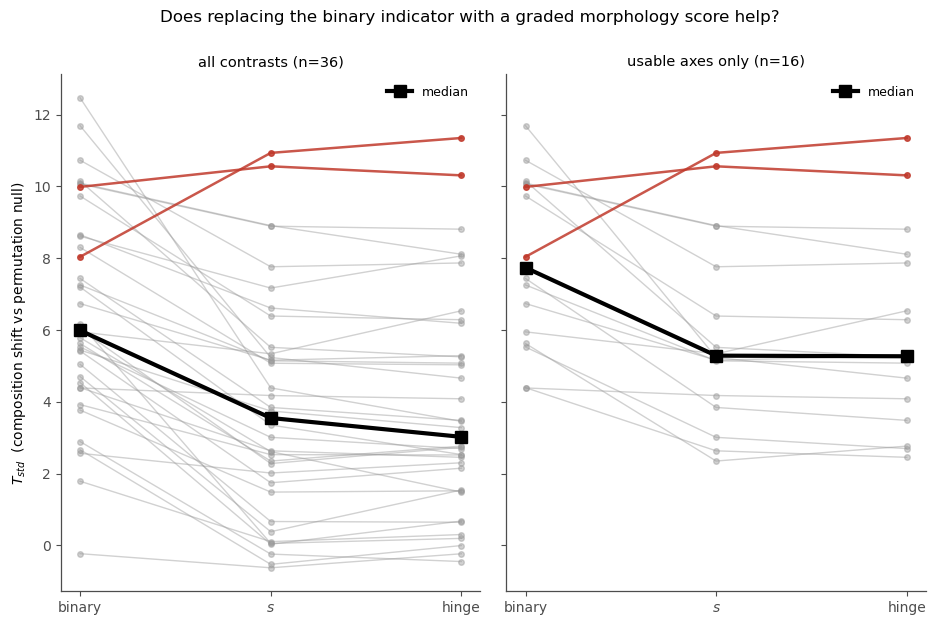

In [4]:
figure = ep.head_to_head(global_stats, quality)


**The head-to-head.** Three one-predictor models per contrast, all z-scored and all carrying one
degree of freedom so they are directly comparable: `binary` (the indicator), `s` (the signed
distance), and `hinge` = `max(s − control mean, 0)`. The statistic is `T_std`, a
permutation-calibrated measure of how far the whole cell-type composition moved from its null.

`T_std` is **scale-invariant** — rescaling a predictor rescales the score and its null SD together —
so the comparison cannot be won by `s` merely having more range than a 0/1 indicator.


In [5]:
wide = global_stats.pivot(index="contrast", columns="arm", values="t_std").join(
    quality.set_index("contrast")[["usable", "loo_auc"]])
rows = []
for label, subset in (("all 36", wide), ("usable axes (16)", wide[wide["usable"]])):
    for arm in ("s_z", "hinge_z"):
        delta = (subset[arm] - subset["binary_z"]).dropna()
        rows.append({"set": label, "arm": arm, "wins": int((delta > 0).sum()), "n": len(delta),
                     "median_delta": delta.median(), "wilcoxon_p": stats.wilcoxon(delta)[1]})
display(pd.DataFrame(rows).round(4))


,set,arm,wins,n,median_delta,wilcoxon_p
0,all 36,s_z,2,36,-2.7424,0.0000
1,all 36,hinge_z,3,36,-2.7497,0.0000
2,usable axes (16),s_z,2,16,-1.9365,0.0021
3,usable axes (16),hinge_z,3,16,-2.0797,0.0063


**Finding 1.** The binary indicator wins in 34 of 36 contrasts (14 of 16 among validated axes),
median ΔT_std ≈ −2.7. Restricting to good axes does not rescue it, and neither does the hinge. As a
*replacement* for the class label, the morphology score loses — decisively and reproducibly.

Worth being clear about what this does and does not say: it says a graded morphological score is a
worse single predictor than knowing which embryos were injected. It says nothing yet about whether
morphology adds anything *on top of* that knowledge. That is §4.

---

## 2. The two effects are strongly aligned, with ~17% of the variance elsewhere


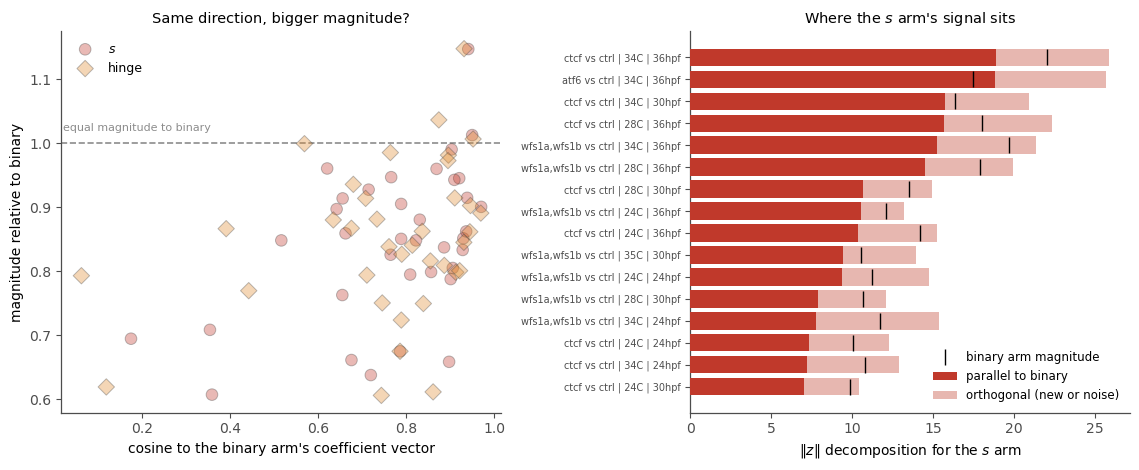

In [6]:
figure = ep.geometry_plot(geometry, quality)


In [7]:
merged = geometry.merge(quality[["contrast", "usable"]], on="contrast")
rows = []
for arm in ("s_z", "hinge_z"):
    block = merged[(merged["arm"] == arm) & merged["usable"]]
    cosine = block["cosine_to_binary"].median()
    rows.append({
        "arm": arm,
        "median_cosine_to_binary": cosine,
        "shared_variance (cos^2)": cosine ** 2,
        "orthogonal_variance (1-cos^2)": 1 - cosine ** 2,
        "orthogonal_fraction_of_length": (block["orthogonal_component"] / block["norm"]).median(),
        "median_magnitude_ratio": (block["norm"] / block["norm_binary"]).median(),
    })
pd.DataFrame(rows).round(3)


,arm,median_cosine_to_binary,shared_variance (cos^2),orthogonal_variance (1-cos^2),orthogonal_fraction_of_length,median_magnitude_ratio
0,s_z,0.913,0.833,0.167,0.408,0.891
1,hinge_z,0.911,0.830,0.170,0.412,0.877


**Finding 2.** Coefficient vectors from the `s` arm and the `binary` arm point in nearly the same
direction — median cosine **0.91** across validated contrasts. Morphology is not finding a different
transcriptional axis; it is finding the same one.

The residual deserves care because two framings of it differ by a factor of two, and both are
correct:

- **~17% of the variance** is orthogonal to the binary contrast (`1 − cos²`)
- **~41% of the vector length** is orthogonal (`sqrt(1 − cos²)`)

The variance framing is the more conservative and the one quoted above. Whether that residual is
real biology or noise is **not resolved here**, and is most likely case-dependent — §5 shows that in
some contrasts it corresponds to genuinely new cell types, while in most it does not.

Magnitude ratio is 0.89: the same signal, slightly attenuated. That is the signature of a noisier
proxy for group membership rather than a sharper one.

---

## 3. Escapers are perturbed; the severity split is directionally right but weak

Crispants are split at the **upper edge of the observed control range**: an "escaper" is an injected
embryo whose `s` falls entirely inside the controls' span. Note this is deliberately the most
permissive definition available, and the category is still thin — for a structural reason. A contrast
has a trustworthy axis precisely when the groups separate cleanly, which is when few crispants land
in control territory. **Escaper-rich and axis-trustworthy are in direct tension.** 21 of 36 contrasts
have at least 4 embryos in both cells.

Embryos are never *dropped* on the basis of `s`. Deleting the wildtype-looking crispants would remove
observations conditional on a label-derived quantity — precisely those nearest the decision boundary,
whose transcriptomes are presumably also the most control-like — and would mechanically widen the
group gap.


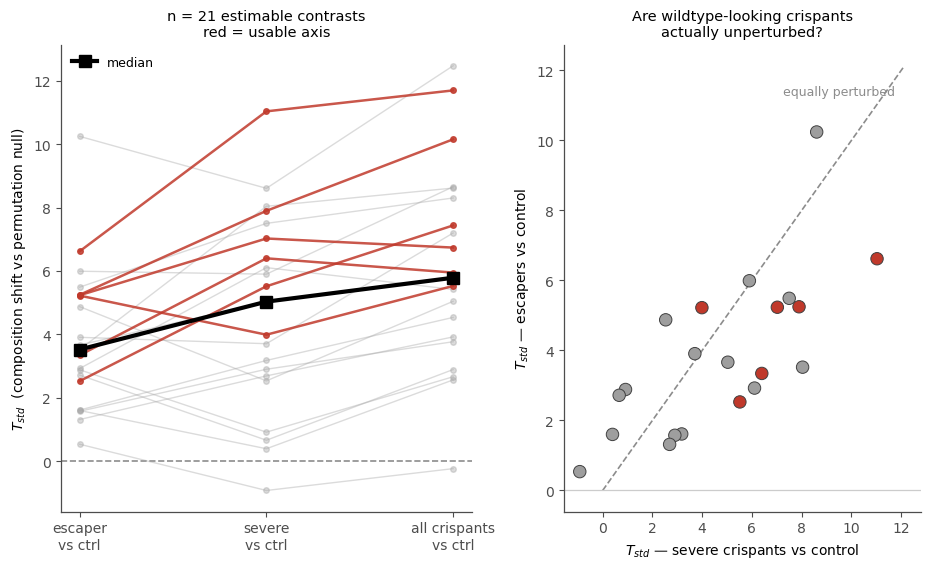

In [8]:
figure = ep.three_level_plot(global_stats, quality)


In [9]:
rows = []
for arm in ("escaper_vs_control", "severe_vs_control", "severe_vs_escaper", "binary_z"):
    block = global_stats[global_stats["arm"] == arm]
    rows.append({"arm": arm, "n_contrasts": len(block),
                 "median_T_std": block["t_std"].median(),
                 "p_global_lt_05": int((block["p_global"] < 0.05).sum()),
                 "median_hits_q10": block["n_hits_q10"].median()})
display(pd.DataFrame(rows).round(3))

paired = (global_stats[global_stats["arm"] == "escaper_vs_control"][["contrast", "t_std"]]
          .merge(global_stats[global_stats["arm"] == "severe_vs_control"][["contrast", "t_std"]],
                 on="contrast", suffixes=("_escaper", "_severe")))
gap = paired["t_std_severe"] - paired["t_std_escaper"]
print(f"INDIRECT paired (severe - escaper, each vs control), n={len(gap)}: "
      f"median {gap.median():+.2f}, severe larger in {int((gap>0).sum())}/{len(gap)}, "
      f"Wilcoxon p = {stats.wilcoxon(gap)[1]:.3f}")
direct = global_stats[global_stats["arm"] == "severe_vs_escaper"]
k, n = int((direct["p_global"] < 0.05).sum()), len(direct)
print(f"DIRECT severe vs escaper (controls dropped), n={n}: {k}/{n} at p<0.05, "
      f"chance {0.05*n:.1f}, binomial p = {binomtest(k, n, 0.05, alternative='greater').pvalue:.4f}")


,arm,n_contrasts,median_T_std,p_global_lt_05,median_hits_q10
0,escaper_vs_control,27,3.909,21,6.0
1,severe_vs_control,30,6.002,26,13.0
2,severe_vs_escaper,21,0.708,4,0.0
3,binary_z,36,5.988,34,11.0


INDIRECT paired (severe - escaper, each vs control), n=21: median +1.37, severe larger in 12/21, Wilcoxon p = 0.111
DIRECT severe vs escaper (controls dropped), n=21: 4/21 at p<0.05, chance 1.1, binomial p = 0.0189


**Finding 3, two halves.**

*The severity split.* Severe crispants trend stronger than escapers, but the **paired** comparison —
the right way to compare, since the two sub-contrasts are estimable on different contrast sets — gives
a median gap of +1.37 in only 12 of 21 contrasts, Wilcoxon **p = 0.11**. Not significant. The
**direct** contrast (severe vs escaper, controls dropped, both groups injected so batch and injection
efficiency cancel) does clear chance at 4/21 versus 1.1 expected, **binomial p = 0.019** — but with
median `T_std` +0.71 and zero cell types surviving FDR. So: directionally right, weakly supported,
not a strong result either way.

*The more striking half.* **Wildtype-looking crispants are substantially transcriptionally
perturbed** — median `T_std` +3.9, significant in 21 of 27 estimable contrasts, median 6 cell types
past FDR. They carry roughly **70%** of the severe group's composition shift while being
morphologically indistinguishable from controls.

That single fact explains §1 and §2. The mosaic-dose premise required escapers to be near-unperturbed
so that appearance would recover dose. They are not. Morphological severity is a **weak and
saturating** proxy for molecular severity, which is why substituting it for a clean label attenuates
rather than sharpens.

---

## 4. Intra-class morphology *does* add information on top of the label

§1 asked whether `s` can **replace** the label. The different question is whether the graded part
adds anything **beyond** it.

`s` is split into the part that *is* the label and the part that is not:
`s_within = s − (own group's mean of s)`. That column has zero mean inside both groups, hence is
exactly orthogonal to the binary indicator (verified at |corr| < 1e-16). Without the centering the
two predictors are near-collinear — `s` was built to separate the groups — and both coefficients
would carry inflated standard errors.

Slopes are fit **separately per group**, which buys a matched negative control: controls also vary
along `s`, and if that variation is measurement noise the control slope should sit at chance. If both
slopes moved together, that would indicate a shared nuisance — developmental stage being the obvious
suspect.


In [10]:
rows = []
for arm, name in (("s_within_crispant", "within-CRISPANT (the dose effect)"),
                  ("s_within_control", "within-CONTROL (negative control)")):
    b = global_stats[global_stats["arm"] == arm]
    k, n = int((b["p_global"] < 0.05).sum()), len(b)
    rows.append({"slope": name, "hits_p<0.05": f"{k}/{n}", "expected_by_chance": round(0.05*n, 1),
                 "binomial_p": binomtest(k, n, 0.05, alternative="greater").pvalue,
                 "median_T_std": b["t_std"].median()})
display(pd.DataFrame(rows).round(4))

pv = global_stats.pivot(index="contrast", columns="arm", values="p_global")
print(f"paired Wilcoxon on the two slopes' p-values: "
      f"p = {stats.wilcoxon(pv['s_within_crispant'], pv['s_within_control'])[1]:.4f}")
print(f"crispant slope more significant than its own control in "
      f"{int((pv['s_within_crispant'] < pv['s_within_control']).sum())}/{len(pv)} contrasts")


,slope,hits_p<0.05,expected_by_chance,binomial_p,median_T_std
0,within-CRISPANT (the dose effect),9/36,1.8,0.0001,0.9005
1,within-CONTROL (negative control),2/36,1.8,0.5433,0.0350


paired Wilcoxon on the two slopes' p-values: p = 0.0026
crispant slope more significant than its own control in 26/36 contrasts


**Finding 4a.** The within-crispant slope is significant in **9–10 of 36** contrasts where chance
gives 1.8 — binomial p ≈ 1e-5 — while the matched negative control sits at the chance rate. Paired,
the crispant slope beats its own control in 26 of 36 contrasts (Wilcoxon p = 0.002).

*(The count moves between 9 and 10 across runs: contrasts sitting near p = 0.05 flip with the
permutation draw at 2000 permutations. The binomial p is ~1e-5 either way.)*

### Which measure of "morphological phenotype" predicts where the slope fires?


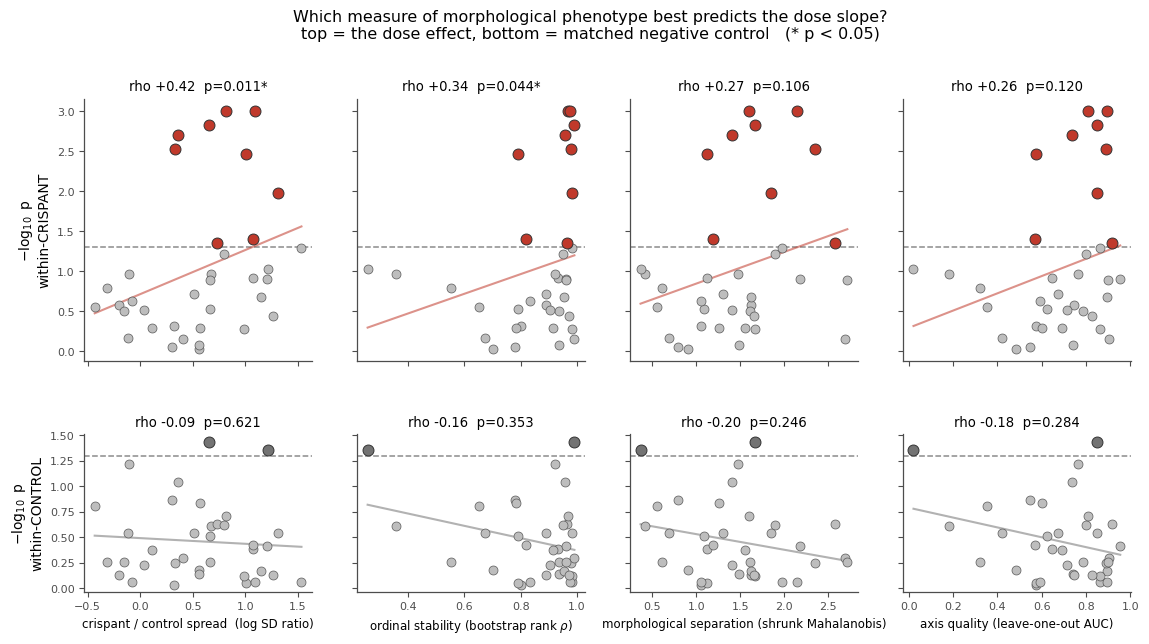

In [11]:
figure = ep.metric_comparison(global_stats, quality)


In [12]:
cri = global_stats[global_stats["arm"] == "s_within_crispant"].set_index("contrast")
ctl = global_stats[global_stats["arm"] == "s_within_control"].set_index("contrast")
qq = quality.set_index("contrast")
rows = []
for metric, label in [("log_sd_ratio", "crispant/control spread"),
                      ("rank_rho_median", "ordinal stability"),
                      ("top_retention_median", "top-tercile retention"),
                      ("separation", "Mahalanobis separation"),
                      ("loo_auc", "LOO-AUC"),
                      ("boot_angle_p95", "bootstrap angle p95 (inverted)")]:
    d = cri[["p_global"]].join(qq[[metric]]).dropna()
    c = ctl[["p_global"]].join(qq[[metric]]).dropna()
    r = stats.spearmanr(d[metric], -np.log10(d["p_global"]))
    rc = stats.spearmanr(c[metric], -np.log10(c["p_global"]))
    rows.append({"metric": label, "rho_vs_slope_significance": r.statistic, "p": r.pvalue,
                 "neg_control_rho": rc.statistic, "neg_control_p": rc.pvalue})
pd.DataFrame(rows).round(3)


,metric,rho_vs_slope_significance,p,neg_control_rho,neg_control_p
0,crispant/control spread,0.417,0.011,-0.085,0.621
1,ordinal stability,0.338,0.044,-0.160,0.353
2,top-tercile retention,0.292,0.084,-0.253,0.136
3,Mahalanobis separation,0.274,0.106,-0.198,0.246
4,LOO-AUC,0.264,0.120,-0.183,0.284
5,bootstrap angle p95 (inverted),-0.195,0.254,0.130,0.451


**Finding 4b.** The slope fires preferentially where the morphological phenotype is stronger, and the
best predictor is **crispant/control spread** (rho +0.42, p = 0.011), with ordinal stability second
(+0.34, p = 0.044). Mahalanobis separation and LOO-AUC are middling (p ≈ 0.11, 0.12); bootstrap angle
is worst.

Two things about how to read that. **The winner is mechanistically the right quantity**, not a fluke
of searching: separation and AUC measure how far crispants sit *from controls*, whereas
crispant/control spread measures how heterogeneous the crispants are *among themselves* — and a
within-group dose analysis can only exploit within-group variation. A cleanly separated but internally
uniform crispant group offers no gradient to detect. **But six metrics were compared**, and Bonferroni
over six puts the best at p ≈ 0.066, so the ranking among them should not be over-read.

Every negative control in that table is flat or slightly negative, which is what rules out "some
contrasts are simply cleaner than others".

So morphology adds information in a **supplementary and perturbation-dependent** capacity: it does
not help everywhere, it helps where there is graded morphology to exploit.

---

## 5. The gain, in cell types

`T_std` is a global statistic. This section asks the concrete question: **does the morphology term
resolve cell types the label alone misses?** Counted by set membership per contrast, not by comparing
totals — the distribution is zero-inflated and heavily skewed, so a median would hide it entirely.

The baseline is not thin: the binary indicator already resolves a median of **11** cell types per
contrast (**16** among validated axes) out of ~50 tested, with only 2 of 36 contrasts finding nothing.
There is plenty of resolution to add to.


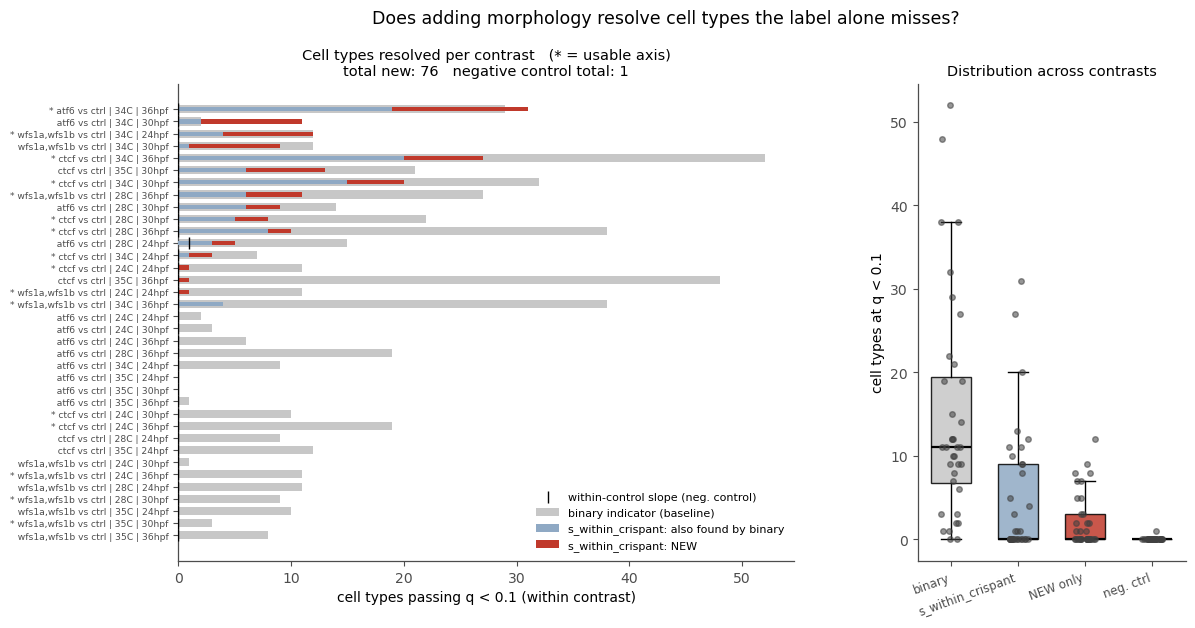

In [13]:
figure, gains = ep.hit_gain_plot(coefficients, quality)


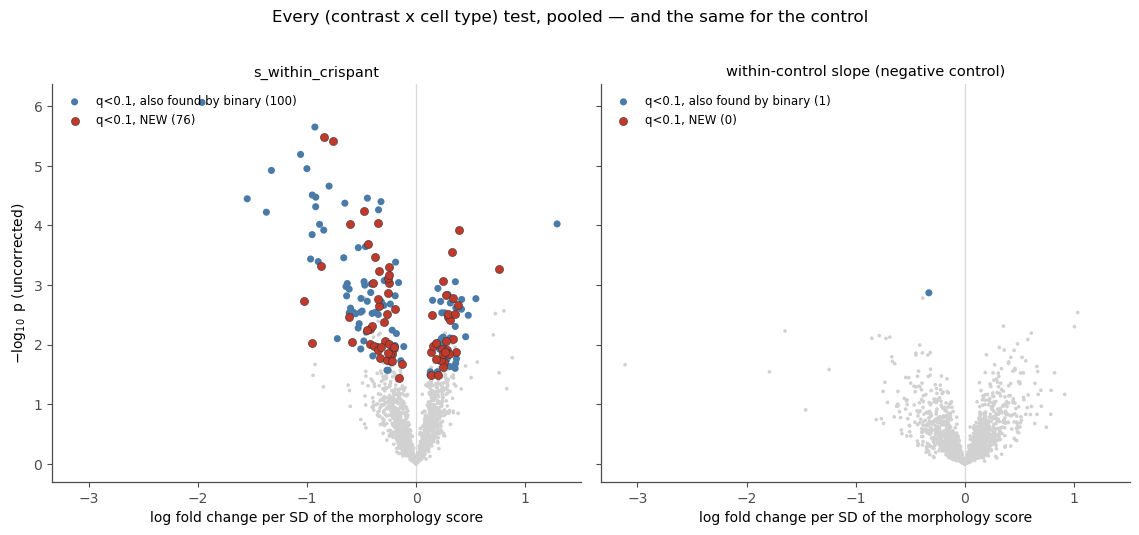

In [14]:
figure = ep.volcano_within(coefficients)


In [15]:
summary = pd.DataFrame([{
    "arm": name,
    "total_hits_q10": int(gains[col].sum()),
    "contrasts_with_any": int((gains[col] > 0).sum()),
    "max_in_one_contrast": int(gains[col].max()),
} for name, col in (("binary indicator", "binary"),
                    ("within-crispant slope (total)", "arm_total"),
                    ("within-crispant slope (NEW only)", "new"),
                    ("within-CONTROL slope (neg. control)", "control"))])
display(summary)

m = (coefficients[coefficients["arm"] == "s_within_crispant"]
     [["contrast", "cell_type", "logFC", "q_value"]]
     .merge(coefficients[coefficients["arm"] == "binary_z"][["contrast", "cell_type", "logFC"]],
            on=["contrast", "cell_type"], suffixes=("_within", "_binary")))
sig = m[m["q_value"] < 0.10]
print(f"sign agreement with the binary arm's logFC, among the {len(sig)} within-slope hits: "
      f"{(np.sign(sig['logFC_within']) == np.sign(sig['logFC_binary'])).mean()*100:.0f}%")


,arm,total_hits_q10,contrasts_with_any,max_in_one_contrast
0,binary indicator,534,34,52
1,within-crispant slope (total),176,17,31
2,within-crispant slope (NEW only),76,16,12
3,within-CONTROL slope (neg. control),1,1,1


sign agreement with the binary arm's logFC, among the 176 within-slope hits: 90%


In [16]:
from collections import Counter
hits = coefficients[(coefficients["arm"] == "s_within_crispant") & (coefficients["q_value"] < 0.10)]
recurrence = Counter(hits["cell_type"])
observed = sum(v >= 3 for v in recurrence.values())

# Null: redistribute the same number of hits per contrast at random among the cell types actually
# tested in that contrast. This absorbs the fact that abundant types are tested everywhere.
rng = np.random.RandomState(0)
tested = (coefficients[coefficients["arm"] == "s_within_crispant"]
          .groupby("contrast")["cell_type"].apply(list))
per_contrast = hits.groupby("contrast").size()
null = []
for _ in range(2000):
    counter = Counter()
    for contrast, k in per_contrast.items():
        counter.update(rng.choice(tested[contrast], size=k, replace=False))
    null.append(sum(v >= 3 for v in counter.values()))
print(f"{len(recurrence)} distinct cell types hit across {len(hits)} hits")
print(f"hit in >=3 contrasts: observed {observed}, null mean {np.mean(null):.1f}, "
      f"p = {(np.array(null) >= observed).mean():.3f}")
display(pd.DataFrame(recurrence.most_common(8), columns=["cell_type", "n_contrasts"]))


65 distinct cell types hit across 176 hits
hit in >=3 contrasts: observed 28, null mean 28.3, p = 0.635


,cell_type,n_contrasts
0,"retinal progenitor cell, retina (atoh7+)",9
1,"ependymal cell, spinal cord",8
2,"neuroblast (sensu Vertebrata), midbrain (ank1a+)",8
3,"neuroblast (sensu Vertebrata), spinal cord",7
4,"neuroblast (sensu Vertebrata), midbrain",6
5,"hatching gland cell, hatching gland",5
6,"radial glial cell, hindbrain",5
7,"glutamatergic neuron, hindbrain (anterior)",5


**Finding 5 — the headline.**

| | count |
|---|---|
| binary indicator, total hits at q<0.10 | 534 |
| within-crispant slope, total hits | 176 |
| **of those, NEW (not found by binary)** | **76**, across 17 of 36 contrasts |
| **within-CONTROL slope (negative control)** | **1**, across all 36 contrasts |

**76 against 1** is the number carrying the claim. Same embryos, same model, same permutation
machinery, same FDR threshold — only which group carries the gradient changed. At q<0.10 one would
expect ~18 false among 176; the control implies the realised false rate is far below that.

Two supporting observations:

- **It behaves like a dose.** Among the 176 hits, the within-slope log fold change shares sign with
  the binary arm's in **90%** of cases. Morphologically severe crispants deviate *further in the same
  direction* as the perturbation effect — a graded amount of the same thing, not a different axis.
  This is also what §2's high cosine predicts.
- **It is not a reproducible cell-type signature.** 65 distinct types are hit; 28 in three or more
  contrasts — but a null redistributing the same hits at random among tested types gives 28.3
  (p ≈ 0.6). Which cell types respond does not recur across perturbations beyond what abundance
  explains. Consistent with the earlier finding that the discriminant directions themselves share no
  structure across contrasts.

The gains are concentrated, not spread: `atf6 | 34C | 36hpf` alone contributes 12 new cell types
(binary finds 29, the slope finds 31), and 19 of 36 contrasts gain nothing.

---

## What this supports, and what it does not

**Supported.** Within a crispant clutch, morphological severity predicts the *magnitude* of the
transcriptional phenotype — same direction, graded amount — resolving 76 cell-type effects the class
label alone misses, against 1 in a matched negative control. Where there is graded morphology to
exploit, morphology adds real information.

**Not supported.** That a graded morphology score should replace the class label (§1, decisively
against). That morphology identifies *which* cell types are dose-sensitive (§5, recurrence at chance).
That morphological severity cleanly stratifies molecular severity (§3, directionally right, weak).

**Open confound.** Contrasts with strong morphological phenotypes are plausibly those where the
perturbation simply *worked better*. Morphology and transcriptome would then be co-symptomatic of
editing efficiency rather than one being informative about the other, and every panel in §4 would look
identical either way. Separating them requires an independent measure of editing efficiency — sequence
the guides, or genotype the F0s.

**Known soft spots, for audit.** The 9-vs-10/36 count in §4a flickers with the permutation draw at
2000 permutations. Six metrics were compared in §4b and the best is quoted. The three-level fit in §3
is estimable in only 21 of 36 contrasts. 18 embryos with morphology are absent from the CDS. FDR is
applied within each contrast, so the 76 figure is a sum over 36 independently-corrected families
rather than a single globally-corrected count.
